![hslu_logo.png](img/hslu_logo.png)

## Week 5

<hr style="border:1px solid black">


# Excercise: Live processing of FCN (fully convolutional network)
---
---
This excercise is to illustrate the live processing of an object detector called FCN.

### Import necessary packages

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time

from utils import plot_img

#### List all available models

In [2]:
all_models = torchvision.models.list_models()
for mod in range(len(all_models)):
    print(all_models[mod])

alexnet
convnext_base
convnext_large
convnext_small
convnext_tiny
deeplabv3_mobilenet_v3_large
deeplabv3_resnet101
deeplabv3_resnet50
densenet121
densenet161
densenet169
densenet201
efficientnet_b0
efficientnet_b1
efficientnet_b2
efficientnet_b3
efficientnet_b4
efficientnet_b5
efficientnet_b6
efficientnet_b7
efficientnet_v2_l
efficientnet_v2_m
efficientnet_v2_s
fasterrcnn_mobilenet_v3_large_320_fpn
fasterrcnn_mobilenet_v3_large_fpn
fasterrcnn_resnet50_fpn
fasterrcnn_resnet50_fpn_v2
fcn_resnet101
fcn_resnet50
fcos_resnet50_fpn
googlenet
inception_v3
keypointrcnn_resnet50_fpn
lraspp_mobilenet_v3_large
maskrcnn_resnet50_fpn
maskrcnn_resnet50_fpn_v2
maxvit_t
mc3_18
mnasnet0_5
mnasnet0_75
mnasnet1_0
mnasnet1_3
mobilenet_v2
mobilenet_v3_large
mobilenet_v3_small
mvit_v1_b
mvit_v2_s
quantized_googlenet
quantized_inception_v3
quantized_mobilenet_v2
quantized_mobilenet_v3_large
quantized_resnet18
quantized_resnet50
quantized_resnext101_32x8d
quantized_resnext101_64x4d
quantized_shufflenet_v2_x0_

#### Select the model
We use FCN due to it yet simple architecture

In [3]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

In [4]:
weights = FCN_ResNet50_Weights.DEFAULT
fcn_resnet50_model = fcn_resnet50(weights=weights)
fcn_resnet50_model.eval()

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

#### Show the number of parameters


backbone.conv1.weight 9408
backbone.bn1.weight 64
backbone.bn1.bias 64
backbone.layer1.0.conv1.weight 4096
backbone.layer1.0.bn1.weight 64
backbone.layer1.0.bn1.bias 64
backbone.layer1.0.conv2.weight 36864
backbone.layer1.0.bn2.weight 64
backbone.layer1.0.bn2.bias 64
backbone.layer1.0.conv3.weight 16384
backbone.layer1.0.bn3.weight 256
backbone.layer1.0.bn3.bias 256
backbone.layer1.0.downsample.0.weight 16384
backbone.layer1.0.downsample.1.weight 256
backbone.layer1.0.downsample.1.bias 256
backbone.layer1.1.conv1.weight 16384
backbone.layer1.1.bn1.weight 64
backbone.layer1.1.bn1.bias 64
backbone.layer1.1.conv2.weight 36864
backbone.layer1.1.bn2.weight 64
backbone.layer1.1.bn2.bias 64
backbone.layer1.1.conv3.weight 16384
backbone.layer1.1.bn3.weight 256
backbone.layer1.1.bn3.bias 256
backbone.layer1.2.conv1.weight 16384
backbone.layer1.2.bn1.weight 64
backbone.layer1.2.bn1.bias 64
backbone.layer1.2.conv2.weight 36864
backbone.layer1.2.bn2.weight 64
backbone.layer1.2.bn2.bias 64
backbone

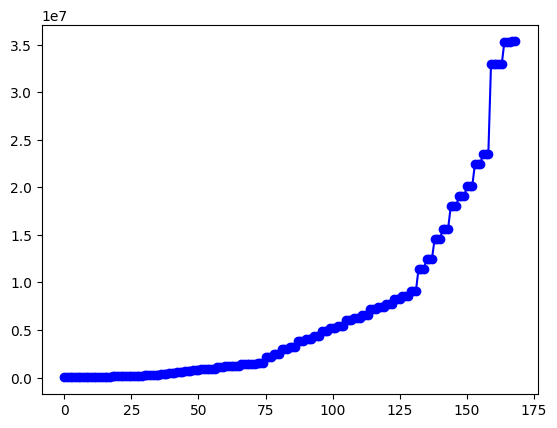

In [5]:
tot_param = []
cum_param = 0
for name, parameter in fcn_resnet50_model.named_parameters():
    print(name, parameter.numel())
    cum_param += parameter.numel()
    tot_param = tot_param + [cum_param]

plt.plot(tot_param, 'bo-')
plt.show()

#### Load an image

Note the shape with the channels at the first position

torch.Size([3, 477, 743])


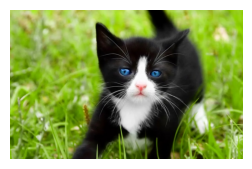

In [6]:
img_name = '../SW03/sample_img/cat.jpg'
img = torchvision.io.read_image(img_name)
print(img.shape)
plot_img(torch.movedim(img, [0],[2]))

#### Transform the image

*Before using the pre-trained models, one must preprocess the image (resize with right resolution/interpolation, apply inference transforms, rescale the values etc). There is no standard way to do this as it depends on how a given model was trained. It can vary across model families, variants or even weight versions. Using the correct preprocessing method is critical and failing to do so may lead to decreased accuracy or incorrect outputs.*
[[ref](https://pytorch.org/vision/stable/models.html#using-the-pre-trained-models)]

The preprocessing is weight specific (a model can have different weight configurations) and therefore the weights (through the method `transforms()`) acutally contain the information on the precise transformation required. 

(The parameter `antialias=True` is only to avoid a PyTorch warning for future compatibility)

In [7]:
img_trans = weights.transforms(antialias=True)(img)
print('\noriginal shape: ', img.shape)
print('transform shape: ', img_trans.shape)
print('\noriginal type: ', img.dtype)
print('transform type: ', img_trans.dtype)
print('\noriginal range: [', torch.min(img).item(), ',', torch.max(img).item(), ']')
print('transform range: [', torch.min(img_trans).item(), ',', torch.max(img_trans).item(), ']')


original shape:  torch.Size([3, 477, 743])
transform shape:  torch.Size([3, 520, 809])

original type:  torch.uint8
transform type:  torch.float32

original range: [ 0 , 255 ]
transform range: [ -2.1179039478302 , 2.640000104904175 ]


#### Apply backbone and classifier

We want to illustrate the idea of the FNC and apply first the ResNet backbone and then the classifier. We visualise the output of the layer with class ID eight, corresponding to the cat category.

input image size: torch.Size([1, 3, 520, 809])
backbone output size:torch.Size([1, 2048, 65, 102])
class_output output size:torch.Size([1, 21, 65, 102])


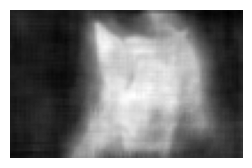

In [8]:
#apply backbone and print the output size
batch = img_trans.unsqueeze(0)
print(f'input image size: {batch.shape}')
output_backbone = fcn_resnet50_model.backbone(batch)["out"]
print(f'backbone output size:{output_backbone.shape}')

#now apply the classifier and print size
class_output = fcn_resnet50_model.classifier(output_backbone)
print(f'class_output output size:{class_output.shape}')

#plot the result of the layer #8 = cat
cat_ID = 8
plot_img(class_output[0,cat_ID].detach())

#### Classify the image


In [9]:
#we have to add the batch dimension (only single image)
batch = img_trans.unsqueeze(0)
print(batch.shape)

#apply the model
prediction = fcn_resnet50_model(batch)

#result is a dict; the key 'out' contains unnormalized probabilities for 20 (+1 background) classes
print('prediction shape:', prediction['out'].shape)

#we calculate normalised probabilities for each pixel
normalized_masks = torch.nn.functional.softmax(prediction['out'], dim=1)

#we determine the "average score" (over image) for each class 
avg_score = torch.mean(normalized_masks.detach()[0].flatten(1), axis=1)
#get highest score (without background = [0])
class_id = torch.argmax(avg_score[1:]).item() + 1

category_name = weights.meta["categories"][class_id]

print(f'\nscore: {100*avg_score[class_id]:.1f},  category: {category_name}')

torch.Size([1, 3, 520, 809])
prediction shape: torch.Size([1, 21, 520, 809])

score: 31.8,  category: cat


#### Plot the bounding box

We use opencv for its simple use of `drawContours`

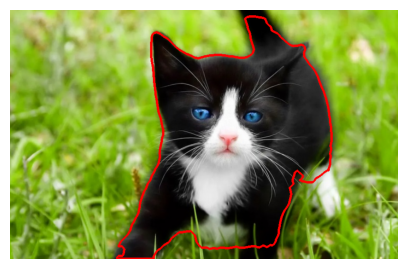

In [10]:
boolean_mask = (normalized_masks.argmax(dim=1) == class_id)[0].numpy()

#find the contours
contours, hierarchy = cv2.findContours(boolean_mask.astype(np.uint8), 
                                                  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 

img_2_plot = cv2.imread(img_name)
#opencv uses BGR as default
img_2_plot = cv2.cvtColor(img_2_plot, cv2.COLOR_BGR2RGB)
#have to resize 
img_2_plot = cv2.resize(img_2_plot, (img_trans.shape[2],img_trans.shape[1]), 0, 0)
cv2.drawContours(img_2_plot, contours, -1, color=(255,0,0), thickness=3) 

plot_img(img_2_plot, figure_size=[5, 5])

### Setup Live Processing


In [ ]:
#list of colors for different object ids
colors=[(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255), (0,255,255)]
# font
font = cv2.FONT_HERSHEY_SIMPLEX
# fontScale
fontScale = .6
# line thickness
thickness = 1
#define a limit score to show object
limit_score = 0.1

# Open the default camera
#to check available capture devices best is matlab :-/
capture_device = 1

cam = cv2.VideoCapture(capture_device)


while True:
    start=time.time()
    ret, frame = cam.read()

    #image conversion 
    image = torch.zeros((3,frame.shape[0],frame.shape[1]),dtype=torch.uint8)
    for plane in range(3):
        image[plane] = torch.tensor(frame[:,:,2-plane])

    img_trans = weights.transforms(antialias=True)(image)
    prediction = fcn_resnet50_model(img_trans.unsqueeze(0))

    stop=time.time()

    #we calculate normalised probabilities and average for each category
    normalized_masks = torch.nn.functional.softmax(prediction['out'], dim=1)
    
    #determine average score (background = [0])
    avg_score = torch.mean(normalized_masks.detach()[0].flatten(1), axis=1)
    
    img_2_plot = frame.copy()
    img_2_plot = cv2.resize(img_2_plot, (img_trans.shape[2],img_trans.shape[1]), 0, 0)

    for class_ind, score in enumerate(avg_score):
        #skip background
        if (0 < class_ind) and (limit_score < score):
            boolean_mask = (normalized_masks.argmax(dim=1) == class_ind)[0].numpy()

            #find the contours
            contours, hierarchy = cv2.findContours(boolean_mask.astype(np.uint8), 
                                                  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 

            cv2.drawContours(img_2_plot, contours, -1, colors[class_ind%6], thickness) 
            x,y,w,h = cv2.boundingRect(contours[0])

            category = weights.meta["categories"][class_ind]      
            cv2.putText(img_2_plot, f'{category}, score={100*score:.1f}', (x,y), 
                                font,  fontScale, colors[class_ind%6], thickness)
          
    cv2.putText(img_2_plot, f'processing time {stop-start:.2f}', (20,20), font, 
                       fontScale, (255,255,255), thickness)

    # Display the captured frame
    cv2.imshow('Camera', img_2_plot)

    key = cv2.waitKeyEx(1)
    if key != -1:
        if key == 101: #'e'
            break     

# Release the capture and writer objects
cam.release()
cv2.destroyWindow('Camera')

KeyboardInterrupt: 

: 